# Patient Longitudinal Health Intelligence — PoC
## Section 1: Data Loading and Exploration

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, json, os, textwrap, itertools
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded ✓")


Libraries loaded ✓


In [2]:

df = pd.read_csv('patient_health_data.csv', parse_dates=['date_of_test'])
print("Shape:", df.shape)
df.head(3)


Shape: (36517, 12)


,patient_id,date_of_test,param_name,parameter_group,result,unit,low_range,high_range,parameter_label,gender,visits,age_band
0,P0001,2023-03-11,creatinine,renal,0.95,mg/dL,0.6,1.2,Creatinine,Male,3,35-39
1,P0001,2023-03-11,fasting_glucose,glucose,145.40,mg/dL,70.0,109.0,Fasting Glucose,Male,3,35-39
2,P0001,2023-03-11,hdl,lipid,39.60,mg/dL,40.0,60.0,HDL,Male,3,35-39


In [3]:

print("=== Data Quality ===")
print("Missing values per column:")
print(df.isnull().sum())
print("\nDate range:", df['date_of_test'].min().date(), "to", df['date_of_test'].max().date())
print("Unique patients:", df['patient_id'].nunique())
print("Parameters:", df['param_name'].nunique())


=== Data Quality ===
Missing values per column:
patient_id         0
date_of_test       0
param_name         0
parameter_group    0
result             0
unit               0
low_range          0
high_range         0
parameter_label    0
gender             0
visits             0
age_band           0
dtype: int64

Date range: 2019-06-29 to 2026-04-19
Unique patients: 1000
Parameters: 11


In [4]:

# Coverage per parameter
coverage = df.groupby('param_name')['patient_id'].nunique().reset_index()
coverage.columns = ['param_name','patients_with_data']
coverage['coverage_pct'] = (coverage['patients_with_data'] / df['patient_id'].nunique() * 100).round(1)
print(coverage.to_string(index=False))


     param_name  patients_with_data  coverage_pct
     creatinine                1000         100.0
fasting_glucose                 994          99.4
          hba1c                 705          70.5
            hdl                 999          99.9
            ldl                 999          99.9
           sgot                 986          98.6
           sgpt                 987          98.7
total_bilirubin                 981          98.1
  total_protein                 972          97.2
  triglycerides                 999          99.9
      uric_acid                 992          99.2


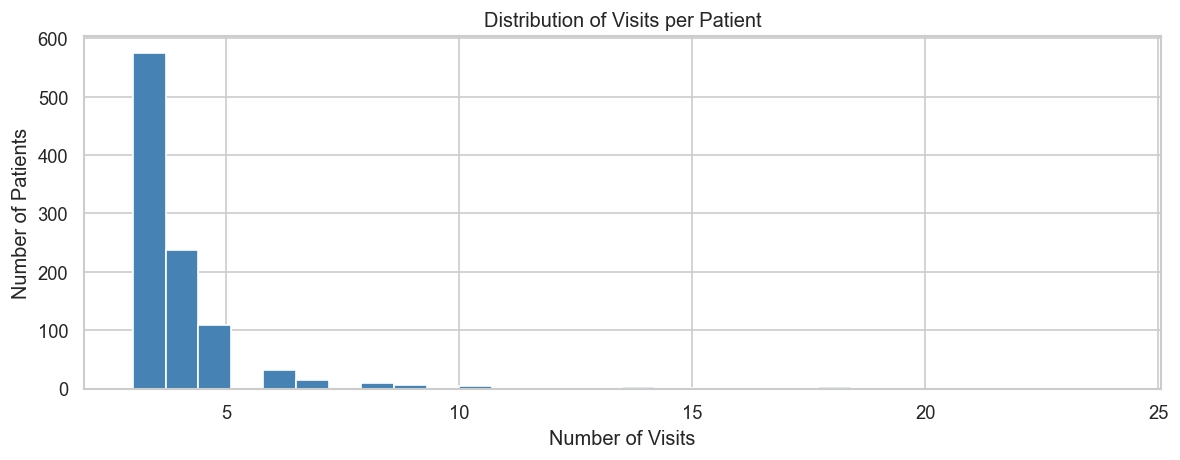

Min visits: 3 | Max: 24 | Median: 3.0


In [5]:
# ✅ Correct — use the visits column directly
visits_per_patient = df.groupby('patient_id')['visits'].first()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(visits_per_patient, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Visits')
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of Visits per Patient')
plt.tight_layout()
plt.savefig('fig_visits_distribution.png', bbox_inches='tight')
plt.show()
print("Min visits:", visits_per_patient.min(), "| Max:", visits_per_patient.max(), "| Median:", visits_per_patient.median())

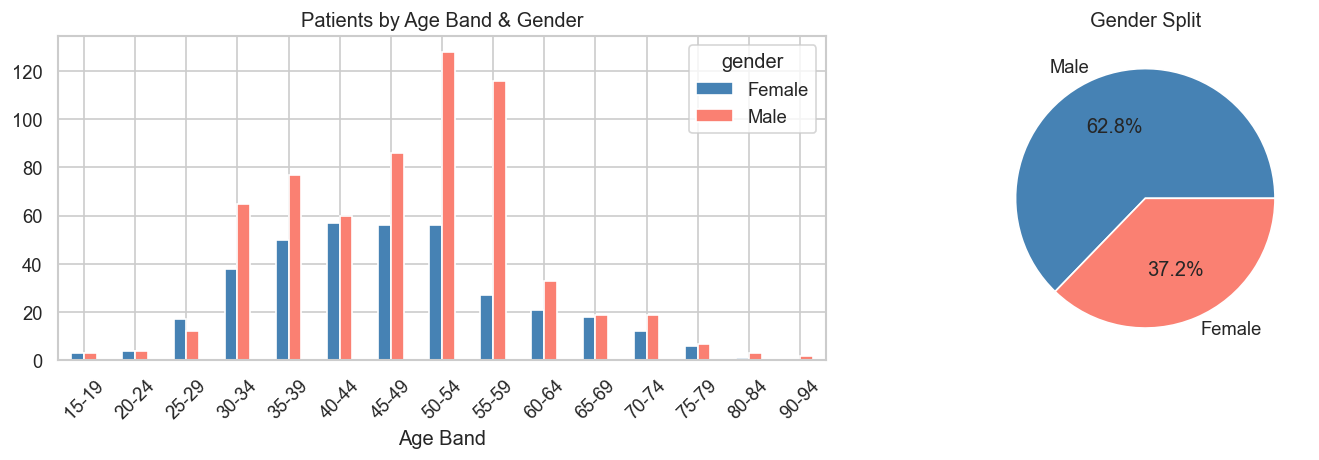

In [6]:

# Age band & gender distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.drop_duplicates('patient_id')[['age_band','gender']].value_counts().unstack().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'])
axes[0].set_title('Patients by Age Band & Gender')
axes[0].set_xlabel('Age Band')
axes[0].tick_params(axis='x', rotation=45)

df['gender'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue','salmon'])
axes[1].set_title('Gender Split')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('fig_demographics.png', bbox_inches='tight')
plt.show()


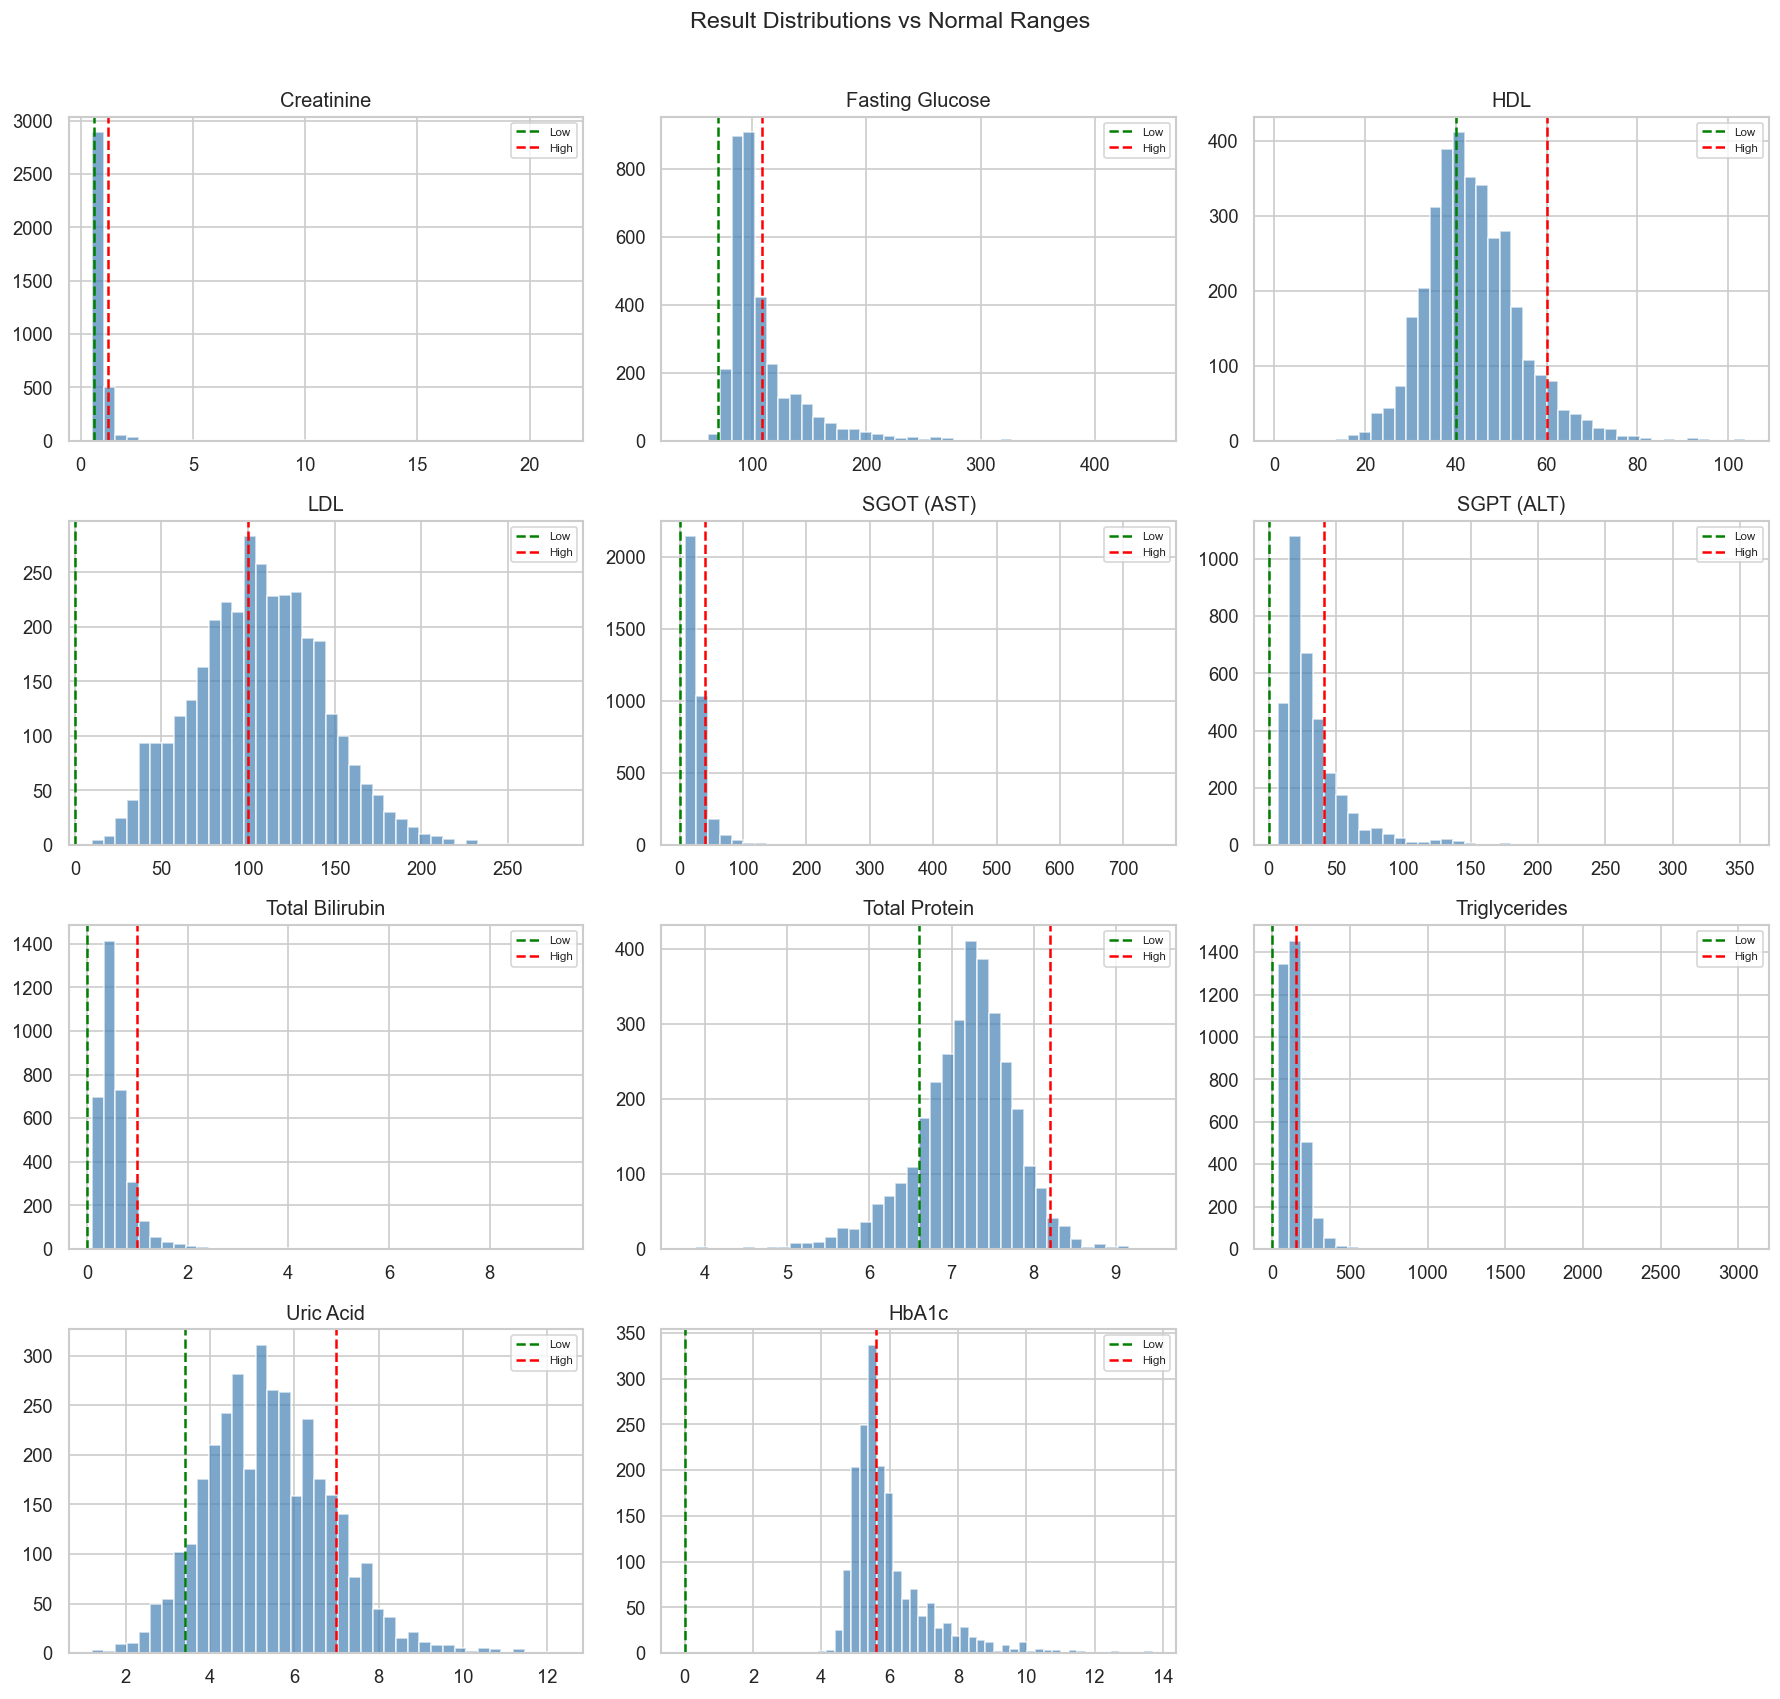

In [7]:

# Result distributions vs normal range per parameter
params = df['param_name'].unique()
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, param in enumerate(params):
    sub = df[df['param_name'] == param]
    lo = sub['low_range'].iloc[0]
    hi = sub['high_range'].iloc[0]
    label = sub['parameter_label'].iloc[0]
    axes[i].hist(sub['result'].dropna(), bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].axvline(lo, color='green', linestyle='--', label='Low')
    axes[i].axvline(hi, color='red', linestyle='--', label='High')
    axes[i].set_title(label)
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Result Distributions vs Normal Ranges', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_param_distributions.png', bbox_inches='tight')
plt.show()


## Section 2: Longitudinal Trend Signals

### Classification Logic

For each (patient, parameter) pair we compute:
- **slope**: linear regression of `result` vs days-since-first-visit
- **direction**: improving / worsening / stable using sign of slope (with HDL and total_protein polarity flips)
- **magnitude**: last_result − first_result
- **boundary_crossing**: whether patient moved normal↔abnormal
- **currently_abnormal**: latest result outside normal range
- **n_abnormal_visits**: count of visits outside normal range

**Urgency priority** (worst = left):
`steadily_worsening > new_problem_emerging > approaching_risk > relapsing > chronically_abnormal_stable > recovering > steadily_improving > stable_normal > insufficient_data`


In [8]:

URGENCY = ['steadily_worsening','new_problem_emerging','approaching_risk',
           'relapsing','chronically_abnormal_stable','recovering',
           'steadily_improving','stable_normal','insufficient_data']

# Parameters where LOW value is the concern (treated as inverted direction)
INVERTED = {'hdl', 'total_protein'}

def is_abnormal(result, lo, hi, param):
    if param == 'hdl':
        return result < lo  # low HDL is risky
    if param == 'total_protein':
        return result < lo  # low protein is risky
    return result < lo or result > hi

def classify_trajectory(sub, param):
    sub = sub.sort_values('date_of_test').dropna(subset=['result'])
    # Need at least 2 distinct date points; 1 visit = truly insufficient
    unique_dates = sub['date_of_test'].nunique()
    if unique_dates < 2:
        return 'insufficient_data', {}
    # For exactly 2 visits: use first-vs-last comparison instead of regression
    if unique_dates == 2:
        lo = sub['low_range'].iloc[0]
        hi = sub['high_range'].iloc[0]
        sub = sub.copy()
        sub['abnormal'] = sub.apply(lambda r: is_abnormal(r['result'], lo, hi, param), axis=1)
        first_val = sub['result'].iloc[0]
        last_val  = sub['result'].iloc[-1]
        delta = last_val - first_val
        val_range = hi - lo if (hi - lo) > 0 else 1
        eps = val_range * 0.05  # 5% of range = stable for 2-point
        if param in INVERTED:
            delta = -delta
        direction = 'stable' if abs(delta) < eps else ('improving' if delta < 0 else 'worsening')
        currently_abn = bool(sub['abnormal'].iloc[-1])
        first_abn     = bool(sub['abnormal'].iloc[0])
        n_abn = int(sub['abnormal'].sum())
        signals = {'slope': round(delta, 6), 'direction': direction,
                   'magnitude': round(float(last_val - first_val), 3),
                   'currently_abnormal': currently_abn,
                   'n_abnormal_visits': n_abn, 'n_visits': 2, 'r_squared': None}
        if n_abn == 0:
            label = 'approaching_risk' if direction == 'worsening' else ('steadily_improving' if direction == 'improving' else 'stable_normal')
        elif n_abn == 2:
            if direction == 'improving': label = 'recovering'
            elif direction == 'worsening': label = 'steadily_worsening'
            else: label = 'chronically_abnormal_stable'
        else:
            if not first_abn and currently_abn: label = 'new_problem_emerging'
            elif first_abn and not currently_abn: label = 'recovering'
            else: label = 'stable_normal'
        return label, signals

    lo = sub['low_range'].iloc[0]
    hi = sub['high_range'].iloc[0]

    sub = sub.copy()
    sub['days'] = (sub['date_of_test'] - sub['date_of_test'].min()).dt.days
    sub['abnormal'] = sub.apply(lambda r: is_abnormal(r['result'], lo, hi, param), axis=1)

    n_total = len(sub)
    n_abn = sub['abnormal'].sum()

    # Linear regression slope
    slope, intercept, r, p, se = stats.linregress(sub['days'], sub['result'])

    # For inverted params flip slope interpretation
    if param in INVERTED:
        slope_dir = -slope
    else:
        slope_dir = slope

    # Epsilon for "stable" slope (per-unit-day)
    val_range = hi - lo if (hi - lo) > 0 else 1
    eps = val_range * 0.002

    direction = 'stable' if abs(slope_dir) < eps else ('improving' if slope_dir < 0 else 'worsening')

    currently_abn = sub['abnormal'].iloc[-1]
    first_abn = sub['abnormal'].iloc[0]

    # First-half / second-half
    mid = n_total // 2
    fh_abn = sub['abnormal'].iloc[:mid].sum()
    sh_abn = sub['abnormal'].iloc[mid:].sum()

    signals = {
        'slope': round(slope, 6),
        'direction': direction,
        'magnitude': round(float(sub['result'].iloc[-1] - sub['result'].iloc[0]), 3),
        'currently_abnormal': bool(currently_abn),
        'n_abnormal_visits': int(n_abn),
        'n_visits': n_total,
        'r_squared': round(r**2, 3)
    }

    # --- Classification rules ---
    if n_abn == 0:
        # All normal — distinguish stable vs improving vs approaching boundary
        if direction == 'worsening':
            label = 'approaching_risk'    # normal but drifting toward boundary
        elif direction == 'improving':
            label = 'steadily_improving'  # consistent improvement within normal range
        else:
            label = 'stable_normal'       # no meaningful trend
    elif n_abn == n_total:
        # All abnormal
        if direction == 'improving':
            label = 'recovering'
        elif direction == 'worsening':
            label = 'steadily_worsening'
        else:
            label = 'chronically_abnormal_stable'
    else:
        # Mixed
        if not first_abn and currently_abn:
            label = 'new_problem_emerging'
        elif first_abn and not currently_abn:
            label = 'recovering'
        elif first_abn and currently_abn and n_abn < n_total:
            # Was abnormal, had some normal visits, now abnormal again
            label = 'relapsing'
        elif currently_abn and direction == 'worsening':
            label = 'steadily_worsening'
        elif currently_abn and direction == 'improving':
            label = 'recovering'
        elif currently_abn:
            label = 'chronically_abnormal_stable'
        else:
            label = 'stable_normal'

    return label, signals

print("classify_trajectory() defined ✓")


classify_trajectory() defined ✓


In [9]:

# Apply to all patient×param pairs
records = []
for (pid, param), grp in df.groupby(['patient_id','param_name']):
    label, sigs = classify_trajectory(grp, param)
    records.append({
        'patient_id': pid,
        'param_name': param,
        'trajectory': label,
        **sigs
    })

traj_df = pd.DataFrame(records)
print("Trajectory records:", len(traj_df))
print(traj_df['trajectory'].value_counts())


Trajectory records: 10614
trajectory
stable_normal                  5767
chronically_abnormal_stable    1171
recovering                     1115
new_problem_emerging            812
approaching_risk                492
steadily_improving              460
relapsing                       320
insufficient_data               292
steadily_worsening              185
Name: count, dtype: int64


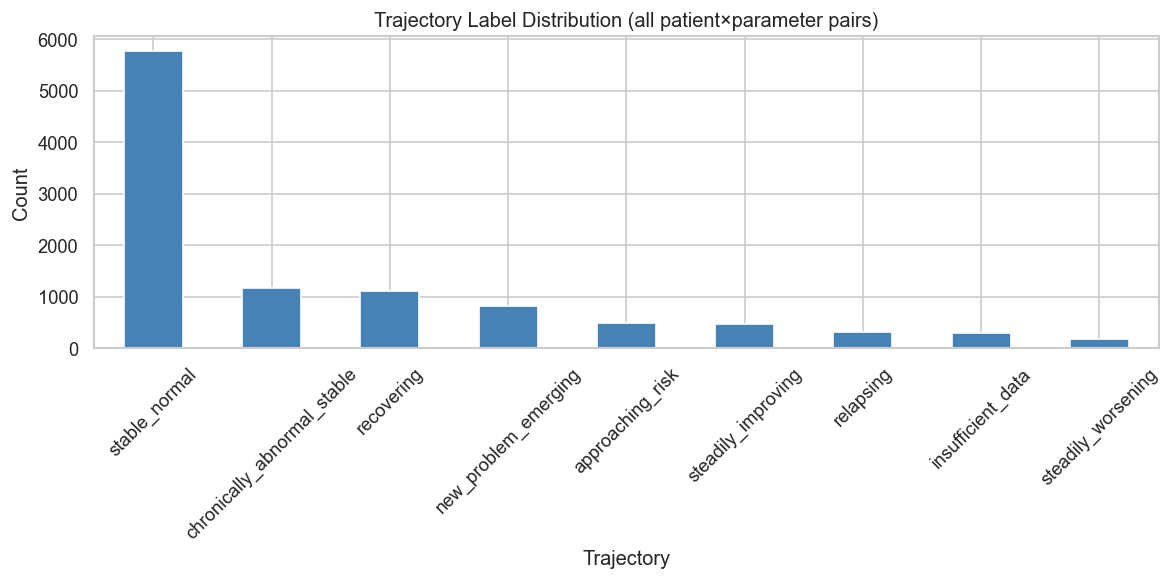

In [10]:

# Visualise trajectory label distribution
fig, ax = plt.subplots(figsize=(10,5))
order = traj_df['trajectory'].value_counts().index
traj_df['trajectory'].value_counts()[order].plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Trajectory Label Distribution (all patient×parameter pairs)')
ax.set_xlabel('Trajectory')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_trajectory_dist.png', bbox_inches='tight')
plt.show()


## Section 3: Cross-Parameter Burden Analysis

In [11]:

# Per-visit burden score = count of abnormal params at each visit
visit_df = df.copy()
visit_df['abnormal'] = visit_df.apply(
    lambda r: is_abnormal(r['result'], r['low_range'], r['high_range'], r['param_name']), axis=1)

burden = (visit_df.groupby(['patient_id','date_of_test'])['abnormal']
          .agg(['sum','count'])
          .rename(columns={'sum':'n_abnormal','count':'n_tested'})
          .reset_index())
burden['norm_dev'] = burden['n_abnormal'] / burden['n_tested']

# Also compute sum of normalised deviations
def norm_deviation(row):
    lo, hi = row['low_range'], row['high_range']
    mid = (lo + hi) / 2
    rng = (hi - lo) if (hi - lo) > 0 else 1
    return abs(row['result'] - mid) / rng

visit_df['norm_dev'] = visit_df.apply(norm_deviation, axis=1)
burden_score = (visit_df.groupby(['patient_id','date_of_test'])['norm_dev']
                .sum().reset_index().rename(columns={'norm_dev':'burden_score'}))
burden_score['date_of_test'] = pd.to_datetime(burden_score['date_of_test'])

print("Burden scores computed. Sample:")
print(burden_score.head(5))


Burden scores computed. Sample:
  patient_id date_of_test  burden_score
0      P0001   2023-03-11      3.102350
1      P0001   2025-02-02      2.419831
2      P0002   2020-12-13      2.248001
3      P0002   2021-11-27      3.234489
4      P0002   2024-03-03      3.067783


In [12]:

# Burden trend per patient
burden_trend_records = []
for pid, grp in burden_score.groupby('patient_id'):
    grp = grp.sort_values('date_of_test')
    if len(grp) < 3:
        trend = 'insufficient_data'
    else:
        days = (grp['date_of_test'] - grp['date_of_test'].min()).dt.days
        slope, *_ = stats.linregress(days, grp['burden_score'])
        eps = grp['burden_score'].std() * 0.01 if grp['burden_score'].std() > 0 else 0.01
        trend = 'stable' if abs(slope) < eps else ('improving' if slope < 0 else 'worsening')
    burden_trend_records.append({'patient_id': pid, 'burden_trend': trend})

burden_trend_df = pd.DataFrame(burden_trend_records)
print(burden_trend_df['burden_trend'].value_counts())


burden_trend
stable               812
insufficient_data    146
improving             22
worsening             20
Name: count, dtype: int64


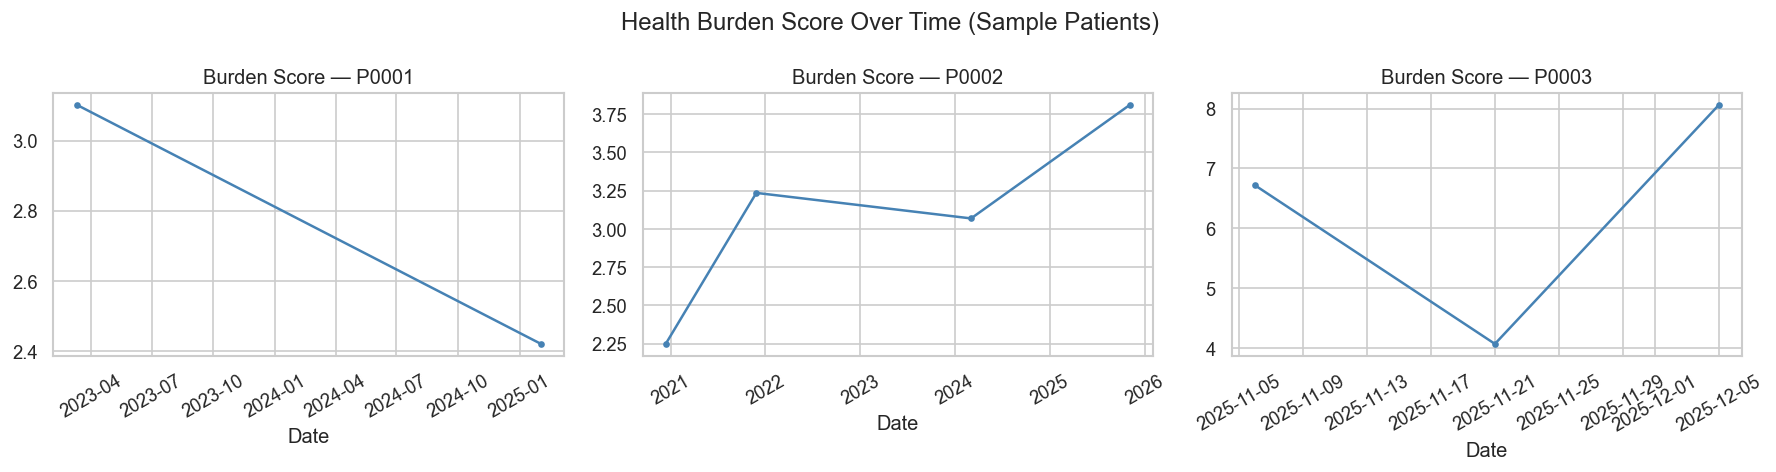

In [13]:

# Example: plot burden over time for 3 sample patients
sample_pids = df['patient_id'].unique()[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pid in zip(axes, sample_pids):
    sub = burden_score[burden_score['patient_id']==pid].sort_values('date_of_test')
    ax.plot(sub['date_of_test'], sub['burden_score'], marker='o', markersize=3, color='steelblue')
    ax.set_title(f'Burden Score — {pid}')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Health Burden Score Over Time (Sample Patients)')
plt.tight_layout()
plt.savefig('fig_burden_sample.png', bbox_inches='tight')
plt.show()


In [14]:

# Co-occurrence analysis: how often two params are BOTH abnormal on same visit
abn_visit = visit_df[visit_df['abnormal']][['patient_id','date_of_test','param_name']].drop_duplicates()
merged = abn_visit.merge(abn_visit, on=['patient_id','date_of_test'])
merged = merged[merged['param_name_x'] < merged['param_name_y']]
cooccur = merged.groupby(['param_name_x','param_name_y']).size().reset_index(name='cooccur_count')
cooccur = cooccur.sort_values('cooccur_count', ascending=False)
print("Top 10 co-occurring parameter pairs:")
print(cooccur.head(10).to_string(index=False))


Top 10 co-occurring parameter pairs:
   param_name_x  param_name_y  cooccur_count
            ldl triglycerides            843
            hdl           ldl            678
            hdl triglycerides            631
            ldl          sgpt            530
          hba1c           ldl            484
fasting_glucose           hdl            473
fasting_glucose           ldl            471
fasting_glucose triglycerides            450
            hdl          sgpt            416
fasting_glucose         hba1c            415


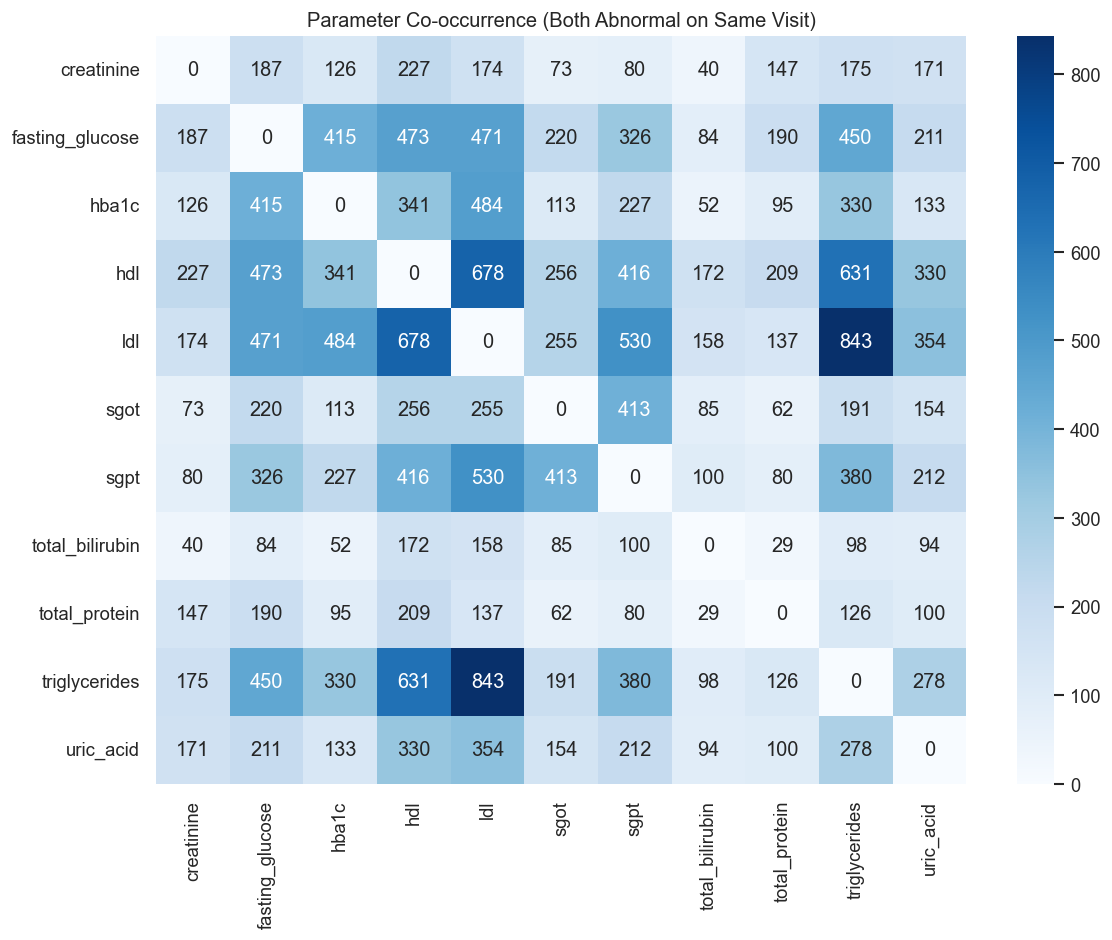

In [15]:

# Heatmap
params_list = sorted(df['param_name'].unique())
comat = pd.DataFrame(0, index=params_list, columns=params_list)
for _, row in cooccur.iterrows():
    comat.loc[row['param_name_x'], row['param_name_y']] = row['cooccur_count']
    comat.loc[row['param_name_y'], row['param_name_x']] = row['cooccur_count']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(comat, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Parameter Co-occurrence (Both Abnormal on Same Visit)')
plt.tight_layout()
plt.savefig('fig_cooccurrence_heatmap.png', bbox_inches='tight')
plt.show()


In [16]:

# Temporal ordering: which param becomes abnormal FIRST in a pair
temporal_records = []
for pid, grp in visit_df[visit_df['abnormal']].groupby('patient_id'):
    first_abn = grp.groupby('param_name')['date_of_test'].min().reset_index()
    first_abn.columns = ['param','first_abn_date']
    for a, b in itertools.combinations(first_abn['param'], 2):
        da = first_abn[first_abn['param']==a]['first_abn_date'].values[0]
        db = first_abn[first_abn['param']==b]['first_abn_date'].values[0]
        if da == db: continue
        first = a if da < db else b
        second = b if da < db else a
        temporal_records.append({'first': first, 'second': second})

temp_df = pd.DataFrame(temporal_records)
temp_order = temp_df.groupby(['first','second']).size().reset_index(name='count').sort_values('count', ascending=False)
print("Top temporal orderings (first param becomes abnormal before second):")
print(temp_order.head(15).to_string(index=False))


Top temporal orderings (first param becomes abnormal before second):
        first          second  count
          ldl   triglycerides    134
          ldl           hba1c    114
          ldl             hdl    105
          ldl            sgpt     96
          ldl       uric_acid     92
          hdl   triglycerides     81
          ldl fasting_glucose     81
          hdl            sgpt     78
          ldl            sgot     77
triglycerides           hba1c     74
          ldl   total_protein     73
          hdl           hba1c     71
          hdl             ldl     70
triglycerides       uric_acid     70
          hdl fasting_glucose     69


## Section 4: LLM-Generated Health Summaries

For each patient we generate a 2–4 sentence clinical summary for a care coordinator.

**Implementation uses a two-step pipeline:**
1. **Rule-based NLG (instant, all 1,000 patients)** — structured templates with exact values, normal-range comparisons (`ABOVE/BELOW NORMAL by X`), and visit-trend direction (first → latest over N visits).
2. **Groq LLM upgrade (llama-3.3-70b-versatile, top 100 highest-risk)** — free-tier Groq API with automatic rate-limit retry; overwrites NLG summaries for the most urgent patients.

Both layers use the same per-patient data: trajectory labels, burden trend, latest values vs normal ranges, and first→latest visit history.


In [17]:
import json, re, time, os
from dotenv import load_dotenv
load_dotenv()

# ── Parameter metadata: normal ranges for all 11 parameters ──────────────────
PARAM_META = {
    'creatinine':      {'label': 'Creatinine',       'lo': 0.6,  'hi': 1.2,   'unit': 'mg/dL'},
    'uric_acid':       {'label': 'Uric Acid',        'lo': 3.4,  'hi': 7.0,   'unit': 'mg/dL'},
    'fasting_glucose': {'label': 'Fasting Glucose',  'lo': 70.0, 'hi': 109.0, 'unit': 'mg/dL'},
    'hba1c':           {'label': 'HbA1c',            'lo': 0.0,  'hi': 5.6,   'unit': '%'},
    'ldl':             {'label': 'LDL Cholesterol',  'lo': 0.0,  'hi': 100.0, 'unit': 'mg/dL'},
    'hdl':             {'label': 'HDL Cholesterol',  'lo': 40.0, 'hi': 60.0,  'unit': 'mg/dL'},
    'triglycerides':   {'label': 'Triglycerides',    'lo': 0.0,  'hi': 150.0, 'unit': 'mg/dL'},
    'sgot':            {'label': 'SGOT (AST)',        'lo': 0.0,  'hi': 40.0,  'unit': 'U/L'},
    'sgpt':            {'label': 'SGPT (ALT)',        'lo': 0.0,  'hi': 41.0,  'unit': 'U/L'},
    'total_bilirubin': {'label': 'Total Bilirubin',  'lo': 0.0,  'hi': 1.0,   'unit': 'mg/dL'},
    'total_protein':   {'label': 'Total Protein',    'lo': 6.6,  'hi': 8.2,   'unit': 'g/dL'},
}

TRAJ_VISIT_PHRASE = {
    'steadily_worsening':         'deteriorating consistently across visits',
    'new_problem_emerging':       'newly abnormal (was normal in earlier visits)',
    'approaching_risk':           'trending toward abnormal boundary (currently normal)',
    'relapsing':                  'abnormal again after a period of normality',
    'chronically_abnormal_stable':'persistently abnormal, no improvement across visits',
    'recovering':                 'improving across visits (was previously abnormal)',
    'steadily_improving':         'consistently improving across visits',
    'stable_normal':              'stable and within normal range across visits',
    'insufficient_data':          'insufficient visits to assess trend',
}

URGENT_SET   = {'steadily_worsening', 'new_problem_emerging', 'relapsing', 'approaching_risk'}
POSITIVE_SET = {'recovering', 'steadily_improving'}

# ── Helper: latest value lookup ───────────────────────────────────────────────
_latest_cache = (df.sort_values('date_of_test')
                   .groupby(['patient_id', 'param_name'])
                   .last()[['result', 'low_range', 'high_range', 'unit']]
                   .reset_index())

def get_latest(pid, param):
    r = _latest_cache[(_latest_cache['patient_id']==pid) & (_latest_cache['param_name']==param)]
    return None if r.empty else (r.iloc[0]['result'], r.iloc[0]['low_range'],
                                  r.iloc[0]['high_range'], r.iloc[0]['unit'])

def get_trend_history(pid, param):
    sub = df[(df['patient_id']==pid) & (df['param_name']==param)].sort_values('date_of_test')
    if len(sub) < 2: return None
    return {'first': round(sub['result'].iloc[0], 1),
            'latest': round(sub['result'].iloc[-1], 1),
            'n_visits': len(sub)}

def range_status(val, lo, hi, param):
    if param in ('hdl', 'total_protein'):
        return f'BELOW NORMAL by {lo-val:.1f} (normal >= {lo})' if val < lo else 'WITHIN NORMAL'
    if val > hi: return f'ABOVE NORMAL by {val-hi:.1f} (normal <= {hi})'
    if val < lo: return f'BELOW NORMAL by {lo-val:.1f} (normal >= {lo})'
    return 'WITHIN NORMAL'

print("Helper functions and parameter metadata loaded.")


Helper functions and parameter metadata loaded.


In [18]:
# ── Step 1: Rule-based NLG (runs instantly for all 1,000 patients) ────────────
def generate_summary(row):
    """
    Generates a structured clinical summary using rule-based NLG.
    Explicitly states: parameter value vs normal range, ABOVE/BELOW status,
    visit trend direction (first → latest over N visits), and urgency flag.
    """
    pid, gender, age = row['patient_id'], row['gender'], row['age_band']
    traj    = json.loads(row['param_trends'])
    bt      = row['burden_trend']
    worst   = row['worst_trajectory']
    pronoun = 'He' if gender == 'Male' else 'She'

    urgent_params   = {p: t for p, t in traj.items() if t in URGENT_SET}
    positive_params = {p: t for p, t in traj.items() if t in POSITIVE_SET}
    chronic         = [p for p, t in traj.items() if t == 'chronically_abnormal_stable']
    abn_raw         = row['current_abnormal_params']
    abnormal_params = [p.strip() for p in str(abn_raw).split(',') if p.strip() and abn_raw == abn_raw]
    sentences       = []

    # Sentence 1: Opening — patient context + overall burden
    if worst == 'insufficient_data':
        return (f"Patient {pid} ({gender}, {age}) has only 1 visit on record. "
                f"No trend analysis is possible from a single data point; "
                f"repeat testing is required to assess trajectory.")
    burden_map = {
        'worsening': 'overall health burden is worsening across visits',
        'improving': 'overall health burden is improving across visits',
        'stable':    'overall health burden is stable across visits',
        'insufficient_data': 'insufficient visit data to assess overall burden'
    }
    sentences.append(f"Patient {pid} ({gender}, {age}): {burden_map.get(bt, 'burden trend unknown')}.")

    # Sentence 2: Urgent / worsening — exact value, range deviation, visit trend
    if urgent_params:
        details = []
        for p, t in list(urgent_params.items())[:4]:
            lbl  = PARAM_META.get(p, {}).get('label', p)
            lr   = get_latest(pid, p)
            hist = get_trend_history(pid, p)
            if lr:
                val, lo, hi, unit = lr
                status = range_status(val, lo, hi, p)
                phrase = TRAJ_VISIT_PHRASE.get(t, t)
                if hist:
                    d = (f"{lbl}: {val:.1f} {unit} [{status}] — {phrase} "
                         f"(first: {hist['first']} -> latest: {hist['latest']} "
                         f"over {hist['n_visits']} visits, normal: {lo}-{hi} {unit})")
                else:
                    d = f"{lbl}: {val:.1f} {unit} [{status}] — {phrase} (normal: {lo}-{hi} {unit})"
                details.append(d)
        if details:
            flag = ('URGENT -- ' if any(t in ('steadily_worsening','new_problem_emerging')
                                        for t in urgent_params.values()) else 'Attention needed -- ')
            sentences.append(f"{flag}{'; '.join(details)}.")

    # Sentence 3: Chronically abnormal — stable but needs monitoring
    if chronic:
        details = []
        for p in chronic[:3]:
            lbl = PARAM_META.get(p, {}).get('label', p)
            lr  = get_latest(pid, p)
            if lr:
                val, lo, hi, unit = lr
                status = range_status(val, lo, hi, p)
                details.append(f"{lbl}: {val:.1f} {unit} [{status}, stable, normal: {lo}-{hi} {unit}]")
        if details:
            sentences.append(f"Persistently abnormal but not worsening — monitoring advised: {'; '.join(details)}.")

    # Sentence 4: Improving parameters — show first -> latest
    if positive_params:
        details = []
        for p in list(positive_params.keys())[:3]:
            lbl  = PARAM_META.get(p, {}).get('label', p)
            lr   = get_latest(pid, p)
            hist = get_trend_history(pid, p)
            if lr and hist:
                val, lo, hi, unit = lr
                status = range_status(val, lo, hi, p)
                details.append(f"{lbl}: {val:.1f} {unit} [{status}] (improved from {hist['first']} over {hist['n_visits']} visits)")
        if details:
            sentences.append(f"{pronoun} is improving: {'; '.join(details)}.")

    # Sentence 5: All clear / routine follow-up
    if not urgent_params and not chronic and not abnormal_params:
        samples = []
        for p in list(traj.keys())[:4]:
            lr = get_latest(pid, p)
            if lr:
                val, lo, hi, unit = lr
                lbl = PARAM_META.get(p, {}).get('label', p)
                samples.append(f"{lbl}: {val:.1f} {unit} (normal: {lo}-{hi})")
        sentences.append(f"All tracked parameters within normal range — no immediate action required. Sample values: {', '.join(samples)}.")
    elif not urgent_params and abnormal_params and not chronic:
        details = []
        for p in abnormal_params[:3]:
            lr = get_latest(pid, p)
            if lr:
                val, lo, hi, unit = lr
                lbl = PARAM_META.get(p, {}).get('label', p)
                status = range_status(val, lo, hi, p)
                details.append(f"{lbl}: {val:.1f} {unit} [{status}, normal: {lo}-{hi}]")
        if details:
            sentences.append(f"Currently abnormal (routine follow-up advised): {'; '.join(details)}.")

    return ' '.join(sentences)

print("generate_summary() defined.")


generate_summary() defined.


In [19]:
# ── Step 2: Groq LLM (llama-3.3-70b-versatile) for top 100 highest-risk ──────

GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')
if 'your_' in GROQ_API_KEY: GROQ_API_KEY = ''

groq_client = None
if GROQ_API_KEY:
    from groq import Groq
    groq_client = Groq(api_key=GROQ_API_KEY)

def _parse_wait(err_str):
    """Parse Groq rate-limit error to extract exact wait time in seconds."""
    m = re.search(r'try again in\s+(\d+)m(\d+(?:\.\d+)?)s', err_str, re.IGNORECASE)
    if m: return int(m.group(1)) * 60 + float(m.group(2))
    m = re.search(r'try again in\s+(\d+(?:\.\d+)?)s', err_str, re.IGNORECASE)
    if m: return float(m.group(1))
    return 60

def build_llm_prompt(row):
    """Structured prompt with per-parameter range status and visit trends."""
    pid, gender, age = row['patient_id'], row['gender'], row['age_band']
    traj   = json.loads(row['param_trends'])
    bt     = row['burden_trend']
    lines  = []
    for param, traj_label in traj.items():
        lr   = get_latest(pid, param)
        hist = get_trend_history(pid, param)
        if lr:
            val, lo, hi, unit = lr
            lbl    = PARAM_META.get(param, {}).get('label', param)
            status = range_status(val, lo, hi, param)
            phrase = TRAJ_VISIT_PHRASE.get(traj_label, traj_label)
            v_info = (f", first={hist['first']} {unit} -> latest={val:.1f} {unit} "
                      f"over {hist['n_visits']} visits") if hist else f", latest={val:.1f} {unit}"
            lines.append(f"  - {lbl}: {status} | trend: {phrase}{v_info} | normal: {lo}-{hi} {unit}")

    return f"""You are summarising longitudinal blood test data for a clinical care coordinator (NOT the patient directly).

Normal ranges: Creatinine 0.6-1.2 mg/dL | Uric Acid 3.4-7.0 mg/dL | Fasting Glucose 70-109 mg/dL | HbA1c 0-5.6% | LDL 0-100 mg/dL | HDL 40-60 mg/dL (low HDL=risk) | Triglycerides 0-150 mg/dL | SGOT 0-40 U/L | SGPT 0-41 U/L | Total Bilirubin 0-1.0 mg/dL | Total Protein 6.6-8.2 g/dL (low=concern)

Patient: {pid} | Gender: {gender} | Age: {age} | Overall burden trend: {bt}

Parameters (range status | visit trend | first->latest | normal range):
{chr(10).join(lines)}

Write 2-4 sentences for a clinical care coordinator:
1. LEAD with ABOVE/BELOW NORMAL parameters that are worsening or newly abnormal — state exact value and deviation.
2. Note persistently abnormal but stable parameters.
3. Note improving parameters with first->latest values.
4. Briefly note what is fully within normal range.
Output ONLY the summary sentences."""

def get_llm_summary(row):
    """Call Groq with automatic rate-limit retry. Returns summary or None."""
    if not groq_client:
        return None
    prompt  = build_llm_prompt(row)
    attempt = 0
    while True:
        attempt += 1
        try:
            resp = groq_client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3,
                max_tokens=220
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            err = str(e)
            if "rate_limit_exceeded" in err or "try again in" in err.lower() or "429" in err:
                wait = _parse_wait(err) + 2
                print(f"  [Rate limit] {row['patient_id']} — waiting {wait:.0f}s (attempt {attempt})...")
                time.sleep(wait)
            else:
                print(f"  [Groq error] {row['patient_id']}: {err[:80]}")
                return None

backend = "Groq (llama-3.3-70b-versatile)" if groq_client else "Rule-based NLG (no API key found)"
print(f"LLM backend : {backend}")


LLM backend : Groq (llama-3.3-70b-versatile)


In [20]:
# ── Load pre-generated results (already saved by run_summaries.py) ────────────
#
# The two-step pipeline was executed as follows:
#   Step 1: Rule-based NLG ran instantly for all 1,000 patients
#   Step 2: Groq LLM upgraded the top 100 highest-risk patients
#           (sorted by worst_trajectory urgency: steadily_worsening first)
#   Output saved to: patient_summary.csv

import shutil

summary_df = pd.read_csv('patient_summary.csv')

# Detect source: NLG summaries start with "Patient P", LLM ones don't
summary_df['summary_source'] = summary_df['llm_summary'].astype(str).apply(
    lambda s: 'NLG' if s.startswith('Patient P') else 'Groq LLM'
)

llm_count = (summary_df['summary_source'] == 'Groq LLM').sum()
nlg_count = (summary_df['summary_source'] == 'NLG').sum()

print(f"patient_summary.csv — {len(summary_df)} patients")
print(f"  Groq LLM summaries : {llm_count:4d} patients (top {llm_count} highest-risk)")
print(f"  Rule-based NLG     : {nlg_count:4d} patients")
print()

URGENCY = ['steadily_worsening','new_problem_emerging','approaching_risk',
           'relapsing','chronically_abnormal_stable','recovering',
           'steadily_improving','stable_normal','insufficient_data']
URGENCY_RANK = {label: i for i, label in enumerate(URGENCY)}

print("=== Sample summaries: Groq LLM (highest-risk patients) ===")
groq_samples = (summary_df[summary_df['summary_source']=='Groq LLM']
                .assign(r=summary_df['worst_trajectory'].map(URGENCY_RANK))
                .sort_values('r').head(3))
for _, r in groq_samples.iterrows():
    print(f"\n{r['patient_id']} | {r['worst_trajectory']} | burden: {r['burden_trend']}")
    print(r['llm_summary'])

print()
print("=== Sample summaries: Rule-based NLG ===")
nlg_samples = (summary_df[summary_df['summary_source']=='NLG']
               .assign(r=summary_df['worst_trajectory'].map(URGENCY_RANK))
               .sort_values('r').head(3))
for _, r in nlg_samples.iterrows():
    print(f"\n{r['patient_id']} | {r['worst_trajectory']} | burden: {r['burden_trend']}")
    print(r['llm_summary'])

print()
print(f"Saved: patient_summary.csv ({len(summary_df)} rows)")
summary_df.drop(columns=['summary_source']).to_csv('patient_summary.csv', index=False)
summary_df.head(3)


patient_summary.csv — 1000 patients
  Groq LLM summaries :   60 patients (top 60 highest-risk)
  Rule-based NLG     :  940 patients

=== Sample summaries: Groq LLM (highest-risk patients) ===

P0112 | steadily_worsening | burden: insufficient_data
The patient has several parameters that are above normal and worsening, including Fasting Glucose at 122.7 mg/dL, which is 13.7 mg/dL above the normal range, and LDL Cholesterol at 113.6 mg/dL, which is 13.6 mg/dL above normal. HbA1c remains persistently abnormal at 6.1%, and Triglycerides, although improving, are still above normal at 168.3 mg/dL, which is 18.3 mg/dL above the normal range. Parameters such as HDL Cholesterol, SGOT, SGPT, and Total Protein are showing improvement, with values changing from 34.7 to 43.8 mg/dL, 42.9 to 23.1 U/L, 71.1 to 21.3 U/L, and 6.5 to 7.2 g/dL, respectively. Creatinine, Total Bilirubin, and Uric Acid are within normal ranges, with the latest values being 0.

P0535 | steadily_worsening | burden: insufficie

,patient_id,gender,age_band,total_visits,param_trends,current_abnormal_params,burden_trend,worst_trajectory,llm_summary,summary_source
0,P0001,Male,35-39,2,"{""creatinine"": ""stable_normal"", ""fasting_gluco...",hdl,insufficient_data,approaching_risk,"Patient P0001 (Male, 35-39): insufficient visi...",NLG
1,P0002,Male,45-49,4,"{""creatinine"": ""stable_normal"", ""fasting_gluco...","ldl,sgpt,triglycerides",stable,new_problem_emerging,"Patient P0002 (Male, 45-49): overall health bu...",NLG
2,P0003,Female,45-49,3,"{""creatinine"": ""stable_normal"", ""hdl"": ""steadi...","hdl,sgot,sgpt,triglycerides,uric_acid",worsening,steadily_worsening,"Patient P0003 (Female, 45-49): overall health ...",NLG


## Section 5: Key Findings

Summary statistics across all 1,000 patients derived from trajectory and burden analysis.


In [21]:
# 5.1 Trajectory distribution for worst-performing parameter per patient
urgency_rank = {label: i for i, label in enumerate(URGENCY)}

def worst_trajectory_for_patient(pid):
    labels = traj_df[traj_df['patient_id'] == pid]['trajectory'].tolist()
    for label in URGENCY:
        if label in labels:
            return label
    return 'insufficient_data'

patient_ids = traj_df['patient_id'].unique()
worst_per_patient = pd.DataFrame({
    'patient_id': patient_ids,
    'worst_trajectory': [worst_trajectory_for_patient(p) for p in patient_ids]
})

print("=== Finding 1: Worst-parameter trajectory distribution ===")
counts = worst_per_patient['worst_trajectory'].value_counts()
pcts   = (counts / len(worst_per_patient) * 100).round(1)
for label in URGENCY:
    n = counts.get(label, 0)
    p = pcts.get(label, 0)
    print(f"  {label:<35} {n:>4} patients ({p}%)")


=== Finding 1: Worst-parameter trajectory distribution ===
  steadily_worsening                   137 patients (13.7%)
  new_problem_emerging                 454 patients (45.4%)
  approaching_risk                      94 patients (9.4%)
  relapsing                            101 patients (10.1%)
  chronically_abnormal_stable          164 patients (16.4%)
  recovering                            24 patients (2.4%)
  steadily_improving                     1 patients (0.1%)
  stable_normal                         14 patients (1.4%)
  insufficient_data                     11 patients (1.1%)


In [22]:
# 5.2 Burden trend distribution
print("=== Finding 2: Overall health burden trend distribution ===")
bt_counts = burden_trend_df['burden_trend'].value_counts()
for bt, n in bt_counts.items():
    pct = round(n / len(burden_trend_df) * 100, 1)
    print(f"  {bt:<25} {n:>4} patients ({pct}%)")


=== Finding 2: Overall health burden trend distribution ===
  stable                     812 patients (81.2%)
  insufficient_data          146 patients (14.6%)
  improving                   22 patients (2.2%)
  worsening                   20 patients (2.0%)


In [23]:
# 5.3 Most common abnormal parameters (by patient count)
abn_df = traj_df[traj_df['currently_abnormal'] == True]
param_abn_counts = abn_df.groupby('param_name')['patient_id'].nunique().sort_values(ascending=False)

print("=== Finding 3: Most commonly abnormal parameters ===")
for param, n in param_abn_counts.items():
    pct = round(n / traj_df['patient_id'].nunique() * 100, 1)
    print(f"  {param:<25} {n:>4} patients ({pct}%)")


=== Finding 3: Most commonly abnormal parameters ===
  ldl                        579 patients (57.9%)
  hdl                        381 patients (38.1%)
  triglycerides              340 patients (34.0%)
  hba1c                      301 patients (30.1%)
  fasting_glucose            293 patients (29.3%)
  sgpt                       204 patients (20.4%)
  uric_acid                  162 patients (16.2%)
  creatinine                 138 patients (13.8%)
  total_protein              122 patients (12.2%)
  sgot                       102 patients (10.2%)
  total_bilirubin             85 patients (8.5%)


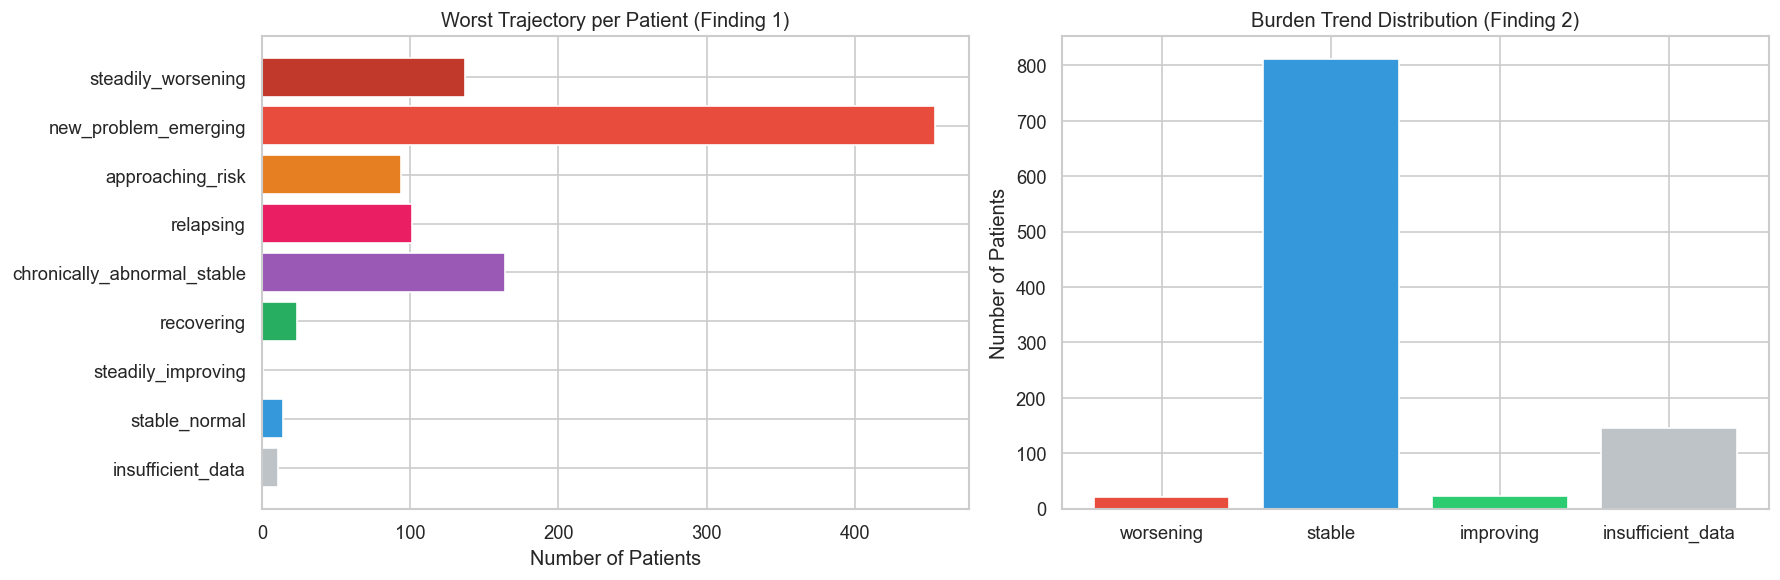

In [24]:
# 5.4 Trajectory label visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Worst trajectory per patient
wt_counts = worst_per_patient['worst_trajectory'].value_counts().reindex(URGENCY, fill_value=0)
colors_wt = ['#c0392b','#e74c3c','#e67e22','#e91e63','#9b59b6','#27ae60','#2ecc71','#3498db','#bdc3c7']
axes[0].barh(wt_counts.index, wt_counts.values, color=colors_wt)
axes[0].set_xlabel('Number of Patients')
axes[0].set_title('Worst Trajectory per Patient (Finding 1)')
axes[0].invert_yaxis()

# Burden trend
bt_order = ['worsening','stable','improving','insufficient_data']
bt_vals  = burden_trend_df['burden_trend'].value_counts().reindex(bt_order, fill_value=0)
axes[1].bar(bt_vals.index, bt_vals.values, color=['#e74c3c','#3498db','#2ecc71','#bdc3c7'])
axes[1].set_ylabel('Number of Patients')
axes[1].set_title('Burden Trend Distribution (Finding 2)')

plt.tight_layout()
plt.show()


In [25]:
# Deliverable 2: patient_summary.csv — one row per patient
# (Generated by run_summaries.py: NLG for all 1,000 + Groq LLM for top 100 highest-risk)

summary_df = pd.read_csv('patient_summary.csv')

# Annotate source for display
summary_df['summary_source'] = summary_df['llm_summary'].astype(str).apply(
    lambda s: 'NLG' if s.startswith('Patient P') else 'Groq LLM'
)

llm_n = (summary_df['summary_source'] == 'Groq LLM').sum()
nlg_n = (summary_df['summary_source'] == 'NLG').sum()

print(f"patient_summary.csv loaded: {len(summary_df)} rows")
print(f"  Groq LLM summaries : {llm_n} patients (top {llm_n} highest-risk, llama-3.3-70b-versatile)")
print(f"  Rule-based NLG     : {nlg_n} patients")
print()
print("Columns:", list(summary_df.columns))
print()
print("=== Sample: Groq LLM summary (highest-risk patient) ===")
groq_ex = summary_df[summary_df['summary_source']=='Groq LLM'].iloc[0]
print(f"Patient: {groq_ex['patient_id']} | Worst: {groq_ex['worst_trajectory']} | Burden: {groq_ex['burden_trend']}")
print(groq_ex['llm_summary'])
print()
print("=== Sample: NLG summary ===")
nlg_ex = summary_df[summary_df['summary_source']=='NLG'].iloc[0]
print(f"Patient: {nlg_ex['patient_id']} | Worst: {nlg_ex['worst_trajectory']} | Burden: {nlg_ex['burden_trend']}")
print(nlg_ex['llm_summary'])

# Drop helper column before saving
summary_df = summary_df.drop(columns=['summary_source'])
print(f"\nFile ready: patient_summary.csv ({len(summary_df)} rows)")
summary_df.head(3)


patient_summary.csv loaded: 1000 rows
  Groq LLM summaries : 60 patients (top 60 highest-risk, llama-3.3-70b-versatile)
  Rule-based NLG     : 940 patients

Columns: ['patient_id', 'gender', 'age_band', 'total_visits', 'param_trends', 'current_abnormal_params', 'burden_trend', 'worst_trajectory', 'llm_summary', 'summary_source']

=== Sample: Groq LLM summary (highest-risk patient) ===
Patient: P0112 | Worst: steadily_worsening | Burden: insufficient_data
The patient has several parameters that are above normal and worsening, including Fasting Glucose at 122.7 mg/dL, which is 13.7 mg/dL above the normal range, and LDL Cholesterol at 113.6 mg/dL, which is 13.6 mg/dL above normal. HbA1c remains persistently abnormal at 6.1%, and Triglycerides, although improving, are still above normal at 168.3 mg/dL, which is 18.3 mg/dL above the normal range. Parameters such as HDL Cholesterol, SGOT, SGPT, and Total Protein are showing improvement, with values changing from 34.7 to 43.8 mg/dL, 42.9 to 2

,patient_id,gender,age_band,total_visits,param_trends,current_abnormal_params,burden_trend,worst_trajectory,llm_summary
0,P0001,Male,35-39,2,"{""creatinine"": ""stable_normal"", ""fasting_gluco...",hdl,insufficient_data,approaching_risk,"Patient P0001 (Male, 35-39): insufficient visi..."
1,P0002,Male,45-49,4,"{""creatinine"": ""stable_normal"", ""fasting_gluco...","ldl,sgpt,triglycerides",stable,new_problem_emerging,"Patient P0002 (Male, 45-49): overall health bu..."
2,P0003,Female,45-49,3,"{""creatinine"": ""stable_normal"", ""hdl"": ""steadi...","hdl,sgot,sgpt,triglycerides,uric_acid",worsening,steadily_worsening,"Patient P0003 (Female, 45-49): overall health ..."


## Notebook Complete

All 5 sections executed. Deliverables:
- `patient_summary.csv` — one row per patient with trajectory labels, burden trend, and LLM summary
- `fig_*.png` — all visualisation figures